# Clasificacion de plantas medicinales con Deep Learning

Dataset: [Herb (Plant) Classification Dataset](https://www.kaggle.com/datasets/ai4a-lab/herb-plant-classification-dataset) (Herbify, 91 especies).
Entrenamiento local con GPU (TensorFlow DirectML).

Flujo del notebook:
1. Descargar el dataset con kagglehub
2. Filtrar clases con suficientes imagenes
3. Split train / val / test estratificado
4. Entrenamiento en 2 fases (base congelada -> fine-tuning)
5. Evaluacion: matriz de confusion y reporte por clase
6. Ficha de usos medicinales + prueba con una foto del test


## 1. Descargar el dataset

Se descarga con `kagglehub` desde Kaggle: `ai4a-lab/herb-plant-classification-dataset`.

In [1]:
from pathlib import Path
import kagglehub

PROYECTO = Path.cwd()
DATA_ROOT = Path(kagglehub.dataset_download('ai4a-lab/herb-plant-classification-dataset'))
print('Dataset en:', DATA_ROOT)

ORIGEN = DATA_ROOT / 'Herbify-Dataset'
if not ORIGEN.exists():
    candidatos = [p for p in DATA_ROOT.rglob('*') if p.is_dir() and any(x.is_dir() for x in p.iterdir())]
    ORIGEN = max(candidatos, key=lambda p: sum(1 for x in p.iterdir() if x.is_dir()))
print('Carpeta de clases:', ORIGEN)


Dataset en: C:\Users\DinamizaTI\.cache\kagglehub\datasets\ai4a-lab\herb-plant-classification-dataset\versions\1
Carpeta de clases: C:\Users\DinamizaTI\.cache\kagglehub\datasets\ai4a-lab\herb-plant-classification-dataset\versions\1\Herbify-Dataset


In [2]:
# El dataset ya queda cacheado por kagglehub; no hace falta subirlo a mano.
print('Listo. Siguiente celda: conteo de imagenes por especie.')


Listo. Siguiente celda: conteo de imagenes por especie.


In [3]:
import os
from pathlib import Path

EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def listar_imagenes(carpeta):
    return [f for f in os.listdir(carpeta)
            if Path(f).suffix.lower() in EXTS]

conteos = []
for d in sorted(os.listdir(ORIGEN)):
    src = os.path.join(ORIGEN, d)
    if os.path.isdir(src):
        n = len(listar_imagenes(src))
        conteos.append((d, n))
        print(f'{d}: {n} imagenes')

print('\nTotal clases:', len(conteos), '| imagenes:', sum(n for _, n in conteos))


Allium cepa (Onion): 88 imagenes
Aloe barbadensis miller (Aloevera): 71 imagenes
Alpinia Galanga (Rasna): 50 imagenes
Amaranthus Viridis (Arive-Dantu): 122 imagenes
Andrographis paniculata (Nelavembu): 68 imagenes
Annona squamosa (Seethapala): 59 imagenes
Artocarpus heterophyllus (Jackfruit): 107 imagenes
Azadirachta indica (Neem): 70 imagenes
Bacopa monnieri (Bhrami): 82 imagenes
Bambusa vulgaris (Bamboo): 48 imagenes
Basella alba (Malabar Spinach): 161 imagenes
Brassica Juncea (Indian Mustard): 34 imagenes
Brassica oleracea (Kohlrabi): 25 imagenes
Calotropis gigantea (Crown flower_Ekka): 35 imagenes
Capsicum annuum (Chilly): 24 imagenes
Cardiospermum halicacabum (Balloon Vine): 38 imagenes
Carica papaya (Papaya): 112 imagenes
Carissa Carandas (Karanda): 74 imagenes
Catharanthus roseus (Catharanthus): 71 imagenes
Chamaecostus cuspidatus (Insulin): 68 imagenes
Cinnamomum camphora (Camphor): 38 imagenes
Citrus limon (Lemon): 146 imagenes
Citrus medica (herelikai): 62 imagenes
Coffea ara

## 2. Seleccionar especies

Las carpetas de Kaggle ya vienen con el nombre cientifico y el nombre comun.
Descartamos clases con pocas fotos: con menos de 50 imagenes el split 70/15/15 no es fiable.

In [5]:
MIN_IMGS = 50
NOMBRES = {carpeta: carpeta for carpeta, n in conteos if n >= MIN_IMGS}

print(f'Clases usadas: {len(NOMBRES)} (minimo {MIN_IMGS} imagenes)')
print('Descartadas:', len(conteos) - len(NOMBRES))
for carpeta, n in sorted(conteos, key=lambda x: -x[1]):
    marca = 'OK' if carpeta in NOMBRES else 'poco'
    print(f'  [{marca:4}] {n:3d}  {carpeta}')


Clases usadas: 57 (minimo 50 imagenes)
Descartadas: 34
  [OK  ] 163  Mentha (Mint)
  [OK  ] 161  Basella alba (Malabar Spinach)
  [OK  ] 158  Spinacia oleracea (Palak(Spinach))
  [OK  ] 152  Ocimum tenuiflorum (Tulsi)
  [OK  ] 146  Citrus limon (Lemon)
  [OK  ] 143  Psidium guajava (Guava)
  [OK  ] 129  Punica granatum (Pomoegranate)
  [OK  ] 127  Murraya koenigii (Curry)
  [OK  ] 122  Amaranthus Viridis (Arive-Dantu)
  [OK  ] 115  Mangifera indica (Mango)
  [OK  ] 112  Carica papaya (Papaya)
  [OK  ] 112  Moringa oleifera (Moringa_Drumstick)
  [OK  ] 107  Artocarpus heterophyllus (Jackfruit)
  [OK  ] 107  Piper betle (Betel)
  [OK  ] 106  Rosa rubiginosa (Rose)
  [OK  ] 100  Nerium oleander (Arali)
  [OK  ]  99  Jasminum (Jasmine)
  [OK  ]  98  Coleus amboinicus (Mexican mint_Doddpathre)
  [OK  ]  98  Tamarindus indica (Tamarind)
  [OK  ]  91  Ricinus communis (Castor)
  [OK  ]  88  Allium cepa (Onion)
  [OK  ]  88  Pongamia pinnata (Pongamia_Honge)
  [OK  ]  85  Hibiscus rosa-sinensi

## 3. Split train / val / test

Separamos 70% entrenamiento, 15% validacion, 15% prueba, de forma estratificada
(la misma proporcion en cada clase).

**Limitacion importante que debes reportar en tu trabajo:** todas las fotos de una
misma clase salen de una sola sesion, asi que comparten fondo, luz y probablemente
la misma planta individual. El test de aqui mide "que tan bien reconoce estas fotos",
no "que tan bien reconoce la especie en el mundo real". Para eso necesitas fotos
nuevas tomadas otro dia y en otro lugar (ver seccion 7).

In [6]:
import random, os, shutil
from PIL import Image

random.seed(42)

BASE = str(PROYECTO / 'dataset')
if os.path.exists(BASE):
    shutil.rmtree(BASE)

P_TRAIN, P_VAL = 0.70, 0.15
IMG_SAVE = (224, 224)
resumen = []

for carpeta, nombre in NOMBRES.items():
    src = os.path.join(ORIGEN, carpeta)
    if not os.path.isdir(src):
        print('No encontrada:', carpeta)
        continue

    archivos = listar_imagenes(src)
    random.shuffle(archivos)

    n = len(archivos)
    i1, i2 = int(n * P_TRAIN), int(n * (P_TRAIN + P_VAL))
    partes = {'train': archivos[:i1], 'val': archivos[i1:i2], 'test': archivos[i2:]}

    for split, lista in partes.items():
        destino = os.path.join(BASE, split, nombre)
        os.makedirs(destino, exist_ok=True)
        for f in lista:
            img = Image.open(os.path.join(src, f)).convert('RGB')
            img = img.resize(IMG_SAVE)
            dest = os.path.join(destino, Path(f).with_suffix('.jpg').name)
            img.save(dest, quality=90)

    resumen.append((nombre, n, len(partes['train']), len(partes['val']), len(partes['test'])))

print(f"{'clase':<55}{'total':>7}{'train':>7}{'val':>6}{'test':>6}")
for r in resumen:
    print(f'{r[0]:<55}{r[1]:>7}{r[2]:>7}{r[3]:>6}{r[4]:>6}')
print('\nTotal imagenes usadas:', sum(x[1] for x in resumen))


clase                                                    total  train   val  test
Allium cepa (Onion)                                         88     61    13    14
Aloe barbadensis miller (Aloevera)                          71     49    11    11
Alpinia Galanga (Rasna)                                     50     35     7     8
Amaranthus Viridis (Arive-Dantu)                           122     85    18    19
Andrographis paniculata (Nelavembu)                         68     47    10    11
Annona squamosa (Seethapala)                                59     41     9     9
Artocarpus heterophyllus (Jackfruit)                       107     74    16    17
Azadirachta indica (Neem)                                   70     49    10    11
Bacopa monnieri (Bhrami)                                    82     57    12    13
Basella alba (Malabar Spinach)                             161    112    24    25
Carica papaya (Papaya)                                     112     78    17    17
Carissa Carandas

## 4. Pipeline de datos y augmentacion

La augmentacion es agresiva a proposito: es tu principal defensa contra que el modelo memorice el fondo.

In [7]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.set_visible_devices(gpus[0], 'GPU')
    tf.config.experimental.set_memory_growth(gpus[0], True)

print('TensorFlow', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

IMG = (224, 224)
BATCH = 32

def cargar(split, shuffle):
    return tf.keras.utils.image_dataset_from_directory(
        f'{BASE}/{split}', image_size=IMG, batch_size=BATCH,
        shuffle=shuffle, seed=42, label_mode='int')

train_ds = cargar('train', True)
val_ds   = cargar('val', False)
test_ds  = cargar('test', False)

CLASES = train_ds.class_names
NUM_CLASES = len(CLASES)
print('\nClases:', NUM_CLASES)
for c in CLASES:
    print(' -', c)


TensorFlow 2.10.1
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Found 3408 files belonging to 57 classes.
Found 734 files belonging to 57 classes.
Found 761 files belonging to 57 classes.

Clases: 57
 - Allium cepa (Onion)
 - Aloe barbadensis miller (Aloevera)
 - Alpinia Galanga (Rasna)
 - Amaranthus Viridis (Arive-Dantu)
 - Andrographis paniculata (Nelavembu)
 - Annona squamosa (Seethapala)
 - Artocarpus heterophyllus (Jackfruit)
 - Azadirachta indica (Neem)
 - Bacopa monnieri (Bhrami)
 - Basella alba (Malabar Spinach)
 - Carica papaya (Papaya)
 - Carissa Carandas (Karanda)
 - Catharanthus roseus (Catharanthus)
 - Chamaecostus cuspidatus (Insulin)
 - Citrus limon (Lemon)
 - Citrus medica (herelikai)
 - Coleus amboinicus (Mexican mint_Doddpathre)
 - Colocasia esculenta (Taro)
 - Coriandrum sativum (Coriander)
 - Cucurbita (Pumpkin)
 - Eclipta prostrata (Bringaraja)
 - Ficus Auriculata (Roxburgh 

In [8]:
AUTOTUNE = tf.data.AUTOTUNE

augmentacion = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical'),
    tf.keras.layers.RandomRotation(0.25),
    tf.keras.layers.RandomZoom(0.25),
    tf.keras.layers.RandomTranslation(0.15, 0.15),
    tf.keras.layers.RandomContrast(0.3),
    tf.keras.layers.RandomBrightness(0.25, value_range=(0, 255)),
], name='augmentacion')

train_ds = train_ds.cache().shuffle(500).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

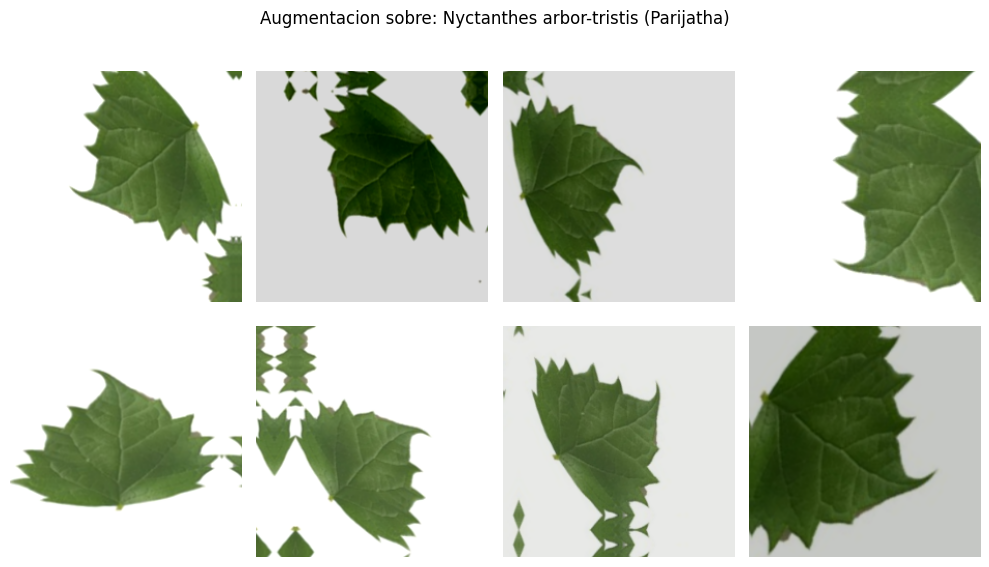

In [9]:
# Visualizar la augmentacion: confirma que las imagenes siguen siendo reconocibles
import matplotlib.pyplot as plt

lote, etiquetas = next(iter(train_ds))
plt.figure(figsize=(10, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    img = augmentacion(tf.expand_dims(lote[0], 0), training=True)[0]
    plt.imshow(tf.cast(img, tf.uint8)); plt.axis('off')
plt.suptitle(f'Augmentacion sobre: {CLASES[etiquetas[0]]}')
plt.tight_layout(); plt.show()

## 5. Modelo: transfer learning con MobileNetV2

### Fase 1 - base congelada

In [10]:
base = tf.keras.applications.MobileNetV2(
    input_shape=IMG + (3,), include_top=False, weights='imagenet')
base.trainable = False

entradas = tf.keras.Input(shape=IMG + (3,))
x = augmentacion(entradas)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.4)(x)
salidas = tf.keras.layers.Dense(NUM_CLASES, activation='softmax')(x)

modelo = tf.keras.Model(entradas, salidas)
modelo.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])
modelo.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 augmentacion (Sequential)   (None, 224, 224, 3)       0         
                                                                 
 tf.math.truediv (TFOpLambda  (None, 224, 224, 3)      0         
 )                                                               
                                                                 
 tf.math.subtract (TFOpLambd  (None, 224, 224, 3)      0         
 a)                                                              
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                             

In [11]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=6,
                                     restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
]

hist1 = modelo.fit(train_ds, validation_data=val_ds, epochs=25, callbacks=callbacks)

Epoch 1/25
107/107 [==============================] - 146s 1s/step - loss: 2.9735 - accuracy: 0.2700 - val_loss: 1.6188 - val_accuracy: 0.6090 - lr: 0.0010
Epoch 2/25
107/107 [==============================] - 148s 1s/step - loss: 1.6368 - accuracy: 0.5496 - val_loss: 1.1224 - val_accuracy: 0.7139 - lr: 0.0010
Epoch 3/25
107/107 [==============================] - 146s 1s/step - loss: 1.2429 - accuracy: 0.6558 - val_loss: 0.9221 - val_accuracy: 0.7657 - lr: 0.0010
Epoch 4/25
107/107 [==============================] - 129s 1s/step - loss: 1.0678 - accuracy: 0.6940 - val_loss: 0.7911 - val_accuracy: 0.7643 - lr: 0.0010
Epoch 5/25
107/107 [==============================] - 128s 1s/step - loss: 0.9165 - accuracy: 0.7397 - val_loss: 0.7415 - val_accuracy: 0.7929 - lr: 0.0010
Epoch 6/25
107/107 [==============================] - 114s 1s/step - loss: 0.8498 - accuracy: 0.7614 - val_loss: 0.6613 - val_accuracy: 0.8338 - lr: 0.0010
Epoch 7/25
107/107 [==============================] - 117s 1s/st

### Fase 2 - fine-tuning

Descongelamos las ultimas capas con un learning rate muy bajo. Si lo subes, destruyes lo aprendido por ImageNet.

In [12]:
base.trainable = True
for capa in base.layers[:-40]:
    capa.trainable = False

modelo.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

hist2 = modelo.fit(train_ds, validation_data=val_ds, epochs=20,
                   callbacks=callbacks)

Epoch 1/20
107/107 [==============================] - 125s 1s/step - loss: 0.3993 - accuracy: 0.8791 - val_loss: 0.3484 - val_accuracy: 0.8883 - lr: 1.0000e-05
Epoch 2/20
107/107 [==============================] - 119s 1s/step - loss: 0.4075 - accuracy: 0.8703 - val_loss: 0.3966 - val_accuracy: 0.8665 - lr: 1.0000e-05
Epoch 3/20
107/107 [==============================] - 118s 1s/step - loss: 0.3774 - accuracy: 0.8841 - val_loss: 0.3903 - val_accuracy: 0.8801 - lr: 1.0000e-05
Epoch 4/20
107/107 [==============================] - 123s 1s/step - loss: 0.3551 - accuracy: 0.8885 - val_loss: 0.3824 - val_accuracy: 0.8801 - lr: 1.0000e-05
Epoch 5/20
107/107 [==============================] - 115s 1s/step - loss: 0.3243 - accuracy: 0.9005 - val_loss: 0.3569 - val_accuracy: 0.8828 - lr: 5.0000e-06
Epoch 6/20
107/107 [==============================] - 112s 1s/step - loss: 0.3096 - accuracy: 0.8994 - val_loss: 0.3676 - val_accuracy: 0.8842 - lr: 5.0000e-06
Epoch 7/20
107/107 [====================

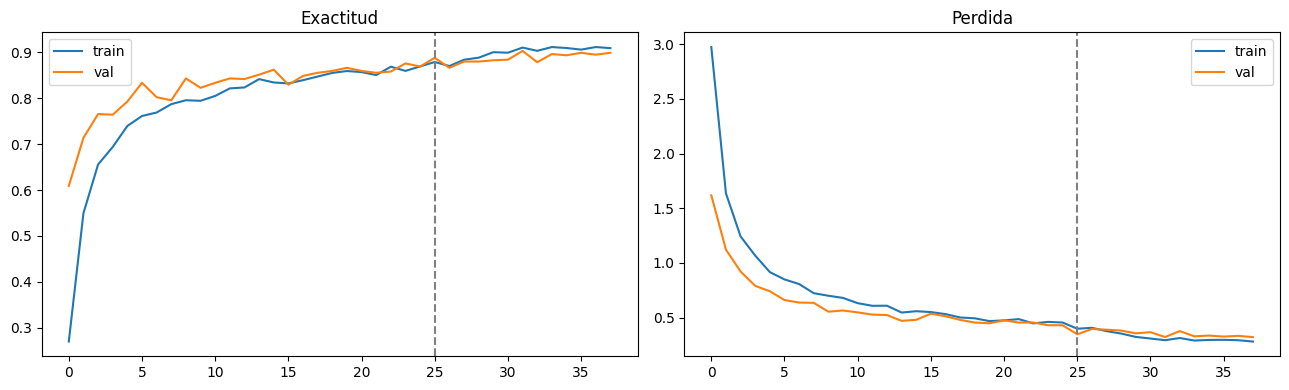

In [20]:
# Curvas de entrenamiento
acc  = hist1.history['accuracy'] + hist2.history['accuracy']
vacc = hist1.history['val_accuracy'] + hist2.history['val_accuracy']
loss  = hist1.history['loss'] + hist2.history['loss']
vloss = hist1.history['val_loss'] + hist2.history['val_loss']
corte = len(hist1.history['accuracy'])

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(acc, label='train'); ax[0].plot(vacc, label='val')
ax[0].axvline(corte, ls='--', c='gray'); ax[0].set_title('Exactitud'); ax[0].legend()
ax[1].plot(loss, label='train'); ax[1].plot(vloss, label='val')
ax[1].axvline(corte, ls='--', c='gray'); ax[1].set_title('Perdida'); ax[1].legend()
plt.tight_layout(); plt.show()

## 6. Evaluacion

La matriz de confusion es lo que de verdad te sirve para el informe: te dice **cuales especies
se confunden entre si**. Si dos clases son especies parecidas (por ejemplo dos *Piper*),
espera confusion ahi y explicalo en tu analisis.

24/24 [==============================] - 2s 56ms/step
                                              precision    recall  f1-score   support

                         Allium cepa (Onion)      1.000     1.000     1.000        14
          Aloe barbadensis miller (Aloevera)      1.000     1.000     1.000        11
                     Alpinia Galanga (Rasna)      0.889     1.000     0.941         8
            Amaranthus Viridis (Arive-Dantu)      0.947     0.947     0.947        19
         Andrographis paniculata (Nelavembu)      0.818     0.818     0.818        11
                Annona squamosa (Seethapala)      1.000     0.778     0.875         9
        Artocarpus heterophyllus (Jackfruit)      0.722     0.765     0.743        17
                   Azadirachta indica (Neem)      0.909     0.909     0.909        11
                    Bacopa monnieri (Bhrami)      1.000     0.923     0.960        13
              Basella alba (Malabar Spinach)      0.917     0.880     0.898        25

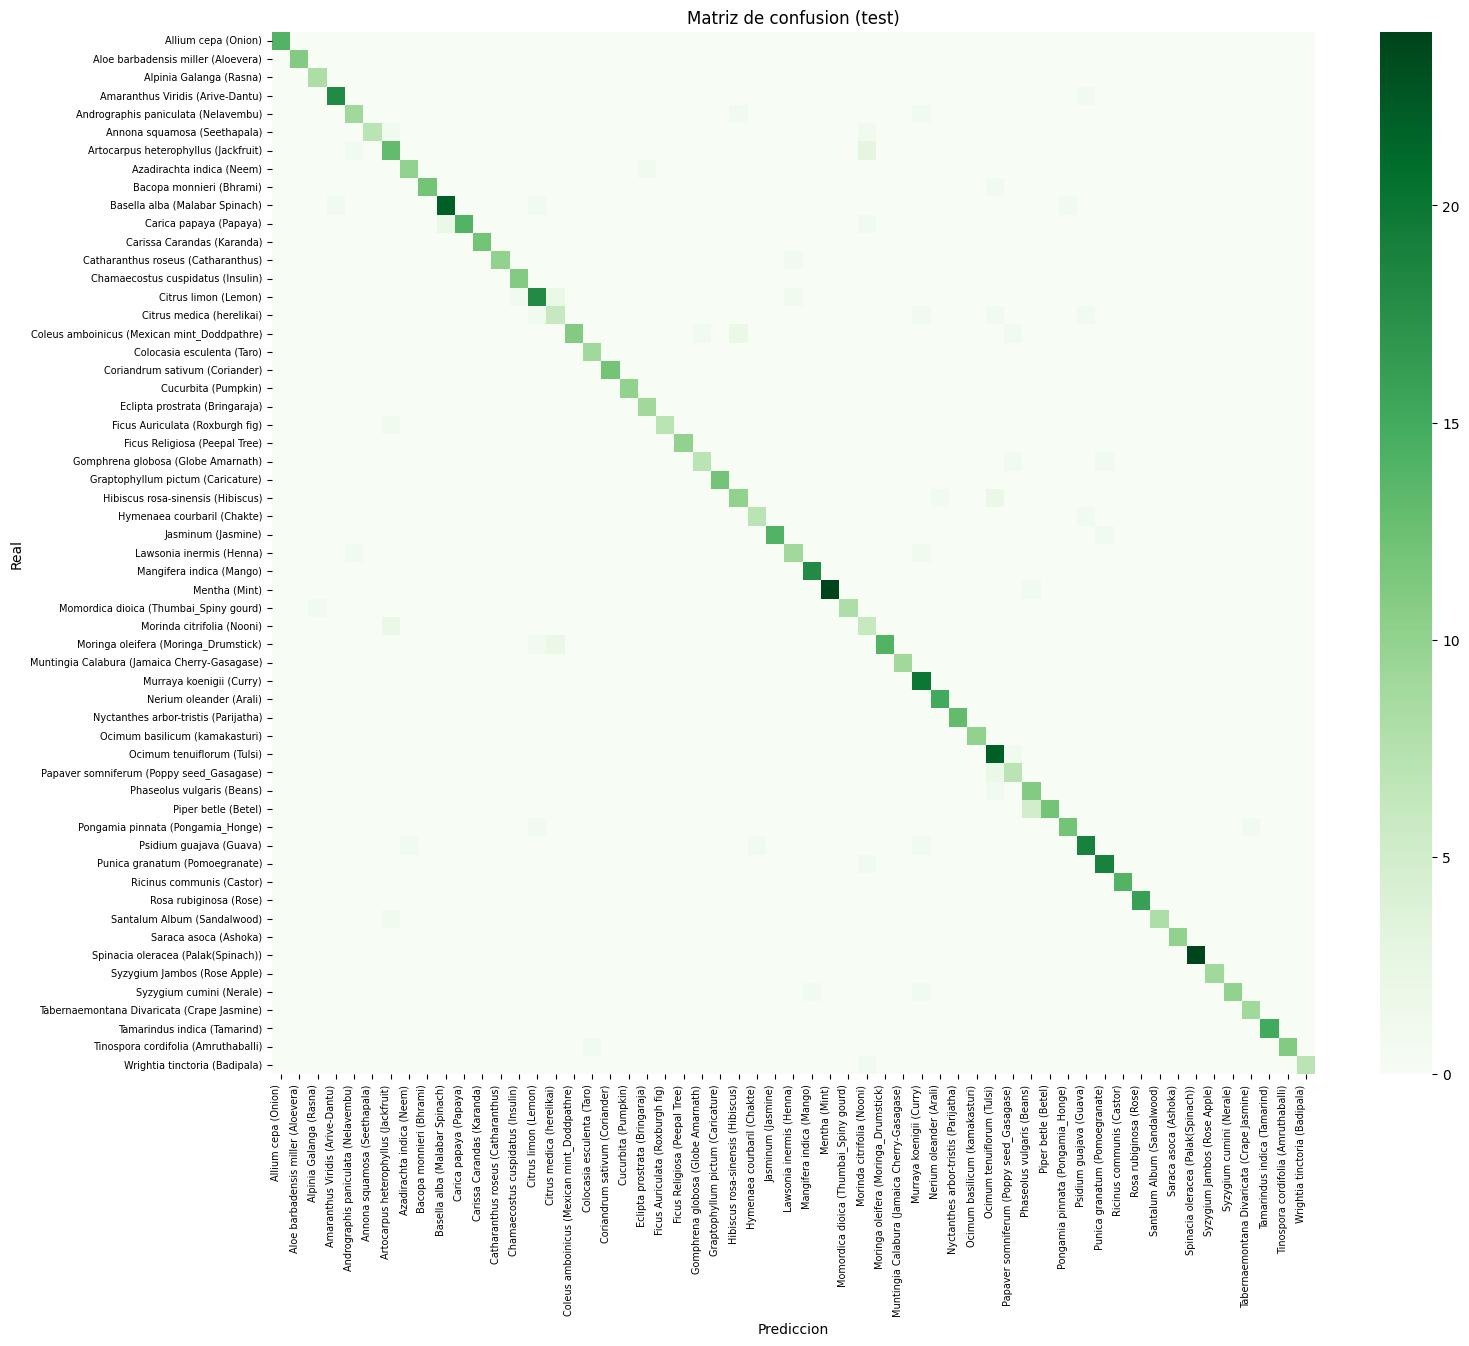

In [14]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_prob = modelo.predict(test_ds)
y_pred = y_prob.argmax(axis=1)

print(classification_report(y_true, y_pred, target_names=CLASES, digits=3))

cm = confusion_matrix(y_true, y_pred)
lado = max(10, min(28, 0.28 * len(CLASES)))
plt.figure(figsize=(lado, lado * 0.85))
sns.heatmap(cm, annot=len(CLASES) <= 20, fmt='d', cmap='Greens',
            xticklabels=CLASES, yticklabels=CLASES)
plt.xlabel('Prediccion'); plt.ylabel('Real')
plt.title('Matriz de confusion (test)')
plt.xticks(rotation=90, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout(); plt.show()


67 errores de 761 imagenes de prueba


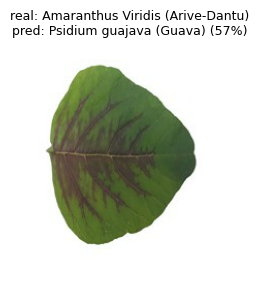

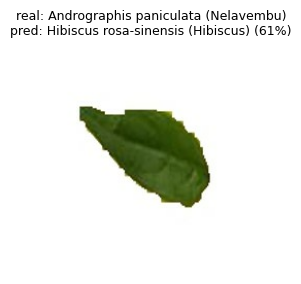

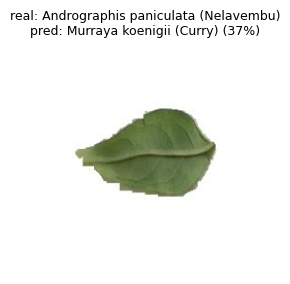

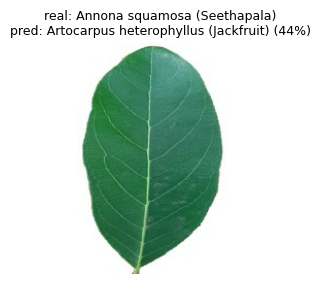

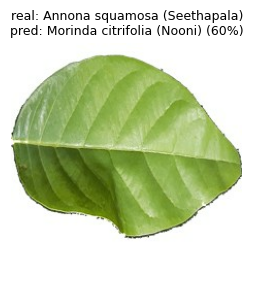

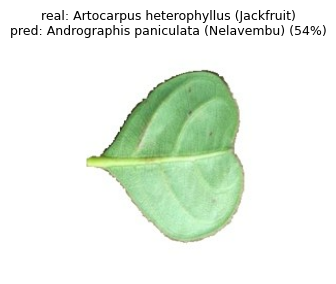

In [15]:
# Ver los errores concretos: util para el analisis cualitativo del informe
errores = np.where(y_true != y_pred)[0]
print(f'{len(errores)} errores de {len(y_true)} imagenes de prueba')

imgs = np.concatenate([x.numpy() for x, _ in test_ds])
for i in errores[:6]:
    plt.figure(figsize=(3, 3))
    plt.imshow(imgs[i].astype('uint8')); plt.axis('off')
    plt.title(f'real: {CLASES[y_true[i]]}\npred: {CLASES[y_pred[i]]} ({y_prob[i].max():.0%})',
              fontsize=9)
    plt.show()

In [16]:
modelo.save(str(PROYECTO / 'modelo_plantas.h5'))

import json
with open(PROYECTO / 'clases.json', 'w', encoding='utf-8') as f:
    json.dump(CLASES, f, ensure_ascii=False, indent=2)

print('Guardado:')
print(' -', PROYECTO / 'modelo_plantas.h5')
print(' -', PROYECTO / 'clases.json')


Guardado:
 - d:\juandmm1233\NoElectivaIII\modelo_plantas.h5
 - d:\juandmm1233\NoElectivaIII\clases.json


## 7. Fichas medicinales

**El modelo NO predice los usos medicinales.** Solo identifica la especie. La informacion
de usos viene de esta tabla, que armas tu con fuentes bibliograficas citables.

Llena una fila por especie y cita de donde sacaste cada dato. En un proyecto de plantas
medicinales, la trazabilidad de la informacion vale tanto como la exactitud del modelo.

In [17]:
import pandas as pd, re

def partir_nombre(clase):
    m = re.match(r'^(.*)\s+\((.*)\)\s*$', clase)
    if m:
        return m.group(1).strip(), m.group(2).strip()
    return clase, ''

filas = []
for c in CLASES:
    cientifico, comun = partir_nombre(c)
    filas.append({
        'clase': c,
        'nombre_comun': comun,
        'nombre_cientifico': cientifico,
        'familia': '',
        'parte_usada': '',
        'usos_tradicionales': '',
        'principios_activos': '',
        'contraindicaciones': '',
        'fuente': 'Herbify / Kaggle ai4a-lab/herb-plant-classification-dataset',
    })

fichas = pd.DataFrame(filas)
ruta_fichas = PROYECTO / 'fichas_medicinales.csv'
fichas.to_csv(ruta_fichas, index=False)
print('Plantilla creada en', ruta_fichas)
fichas.head(10)


Plantilla creada en d:\juandmm1233\NoElectivaIII\fichas_medicinales.csv


,clase,nombre_comun,nombre_cientifico,familia,parte_usada,usos_tradicionales,principios_activos,contraindicaciones,fuente
0,Allium cepa (Onion),Onion,Allium cepa,,,,,,Herbify / Kaggle ai4a-lab/herb-plant-classific...
1,Aloe barbadensis miller (Aloevera),Aloevera,Aloe barbadensis miller,,,,,,Herbify / Kaggle ai4a-lab/herb-plant-classific...
2,Alpinia Galanga (Rasna),Rasna,Alpinia Galanga,,,,,,Herbify / Kaggle ai4a-lab/herb-plant-classific...
3,Amaranthus Viridis (Arive-Dantu),Arive-Dantu,Amaranthus Viridis,,,,,,Herbify / Kaggle ai4a-lab/herb-plant-classific...
4,Andrographis paniculata (Nelavembu),Nelavembu,Andrographis paniculata,,,,,,Herbify / Kaggle ai4a-lab/herb-plant-classific...
5,Annona squamosa (Seethapala),Seethapala,Annona squamosa,,,,,,Herbify / Kaggle ai4a-lab/herb-plant-classific...
6,Artocarpus heterophyllus (Jackfruit),Jackfruit,Artocarpus heterophyllus,,,,,,Herbify / Kaggle ai4a-lab/herb-plant-classific...
7,Azadirachta indica (Neem),Neem,Azadirachta indica,,,,,,Herbify / Kaggle ai4a-lab/herb-plant-classific...
8,Bacopa monnieri (Bhrami),Bhrami,Bacopa monnieri,,,,,,Herbify / Kaggle ai4a-lab/herb-plant-classific...
9,Basella alba (Malabar Spinach),Malabar Spinach,Basella alba,,,,,,Herbify / Kaggle ai4a-lab/herb-plant-classific...


## 8. Probar con una foto nueva

Probando con: d:\juandmm1233\NoElectivaIII\dataset\test\Allium cepa (Onion)\20190824_182037.jpg


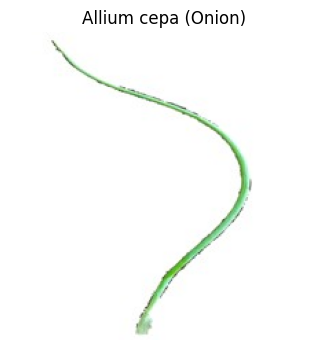

Predicciones:
  Allium cepa (Onion)                                     100.0%
  Momordica dioica (Thumbai_Spiny gourd)                  0.0%
  Tamarindus indica (Tamarind)                            0.0%

--- FICHA ---
clase: Allium cepa (Onion)
nombre_comun: Onion
nombre_cientifico: Allium cepa
fuente: Herbify / Kaggle ai4a-lab/herb-plant-classification-dataset


In [18]:
from PIL import Image
import numpy as np

fichas = pd.read_csv(PROYECTO / 'fichas_medicinales.csv').fillna('')

# Prueba automatica con una imagen del conjunto de test
test_dir = Path(BASE) / 'test'
ejemplos = list(test_dir.rglob('*.jpg'))
ruta = ejemplos[0]
print('Probando con:', ruta)

img = Image.open(ruta).convert('RGB').resize(IMG)
arr = np.expand_dims(np.array(img), 0)
probs = modelo.predict(arr, verbose=0)[0]

orden = probs.argsort()[::-1]
plt.figure(figsize=(4, 4))
plt.imshow(img); plt.axis('off'); plt.title(ruta.parent.name); plt.show()

print('Predicciones:')
for i in orden[:3]:
    print(f'  {CLASES[i]:<55} {probs[i]:.1%}')

top = CLASES[orden[0]]
if probs[orden[0]] < 0.60:
    print('\nConfianza baja. No se recomienda usar esta prediccion.')
else:
    fila = fichas[fichas['clase'] == top]
    if not fila.empty:
        print('\n--- FICHA ---')
        for col in fila.columns:
            if str(fila.iloc[0][col]):
                print(f'{col}: {fila.iloc[0][col]}')


## 9. Demo web con Gradio (opcional)

Te genera un enlace publico para mostrar el proyecto en la sustentacion.

In [24]:
import gradio as gr
from PIL import Image

def clasificar(imagen):
    img = Image.fromarray(imagen).convert('RGB').resize(IMG)
    probs = modelo.predict(np.expand_dims(np.array(img), 0), verbose=0)[0]
    resultados = {CLASES[i]: float(probs[i]) for i in range(len(CLASES))}
    top = CLASES[probs.argmax()]
    if probs.max() < 0.60:
        texto = 'Confianza insuficiente para dar una identificacion.'
    else:
        fila = fichas[fichas['clase'] == top]
        texto = '\n'.join(
            f'**{c}**: {fila.iloc[0][c]}'
            for c in fila.columns if fila.iloc[0][c]
        ) if not fila.empty else ''
    return resultados, texto

gr.Interface(
    fn=clasificar,
    inputs=gr.Image(label='Foto de la planta'),
    outputs=[
        gr.Label(num_top_classes=3, label='Especie'),
        gr.Markdown(label='Ficha'),
    ],
    title='Identificador de plantas medicinales',
    description='Herramienta academica. No sustituye la identificacion botanica ni el criterio medico.',
).launch()


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


Created dataset file at: .gradio\flagged\dataset1.csv


---

## Como subir la exactitud (en orden de impacto)

1. **Mas fotos, y sobre todo mas variadas.** Distintos dias, luces, fondos, angulos, epocas de la planta. Esto importa mas que cualquier cambio de arquitectura.
2. **Un test independiente.** Fotos de las mismas especies tomadas en otro lugar. Si el modelo mantiene la exactitud ahi, tienes un resultado defendible.
3. **Probar EfficientNetB0** cambiando `MobileNetV2` por `EfficientNetB0` (y su `preprocess_input`). Suele dar unos puntos mas.
4. **Class weights** si las clases quedan desbalanceadas.
5. **Recortar el encuadre** a la hoja o flor, para que el fondo pese menos.

## Para el informe

Reporta siempre: exactitud, precision, recall y F1 por clase; la matriz de confusion; y la limitacion
de que el dataset proviene de sesiones unicas por especie. Reconocer esa limitacion explicitamente
es mejor trabajo academico que presentar un 99% sin contexto.
